# Task 2: Predict Future Stock Prices (Short-Term)

**DevelopersHub Corporation — AI/ML Engineering Internship**

## Problem Statement

Short-term stock price movement is notoriously hard to predict, but it's a
great exercise in time-series regression: using a day's trading information
(Open, High, Low, Volume) to estimate that same day's closing price, and by
extension, the next day's.

## Objective

- Load historical daily stock data for a real company (Apple — `AAPL`).
- Use `Open`, `High`, `Low`, and `Volume` as features to predict `Close`.
- Train both a Linear Regression and a Random Forest model.
- Plot actual vs. predicted closing prices to visually compare performance.

## Stock & Data Source

**Apple Inc. (AAPL)** — 506 trading days of daily OHLCV data
(Feb 2015 – Feb 2017).

## ⚠️ A note on data source

The task suggests pulling live data with the `yfinance` library. This
notebook's sandbox network is restricted to a short domain allow-list and
cannot reach Yahoo Finance's servers, so a static historical CSV
(`apple_stock.csv`, sourced from a public GitHub dataset mirror) is used
instead — it has the exact same `Open/High/Low/Close/Volume` structure
`yfinance` would return. The real `yfinance` code is included in Section 1
(commented out / wrapped in a `try/except`) — uncomment it and run on a
machine with normal internet access to pull live data for any ticker.


In [1]:
# ---------------------------------------------------------------
# Imports
# ---------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


## 1. Data Loading

In [2]:
TICKER = "AAPL"

# --- Real yfinance version (requires internet access to Yahoo Finance) ---
# import yfinance as yf
# df = yf.download(TICKER, start="2015-02-17", end="2017-02-17")
# df = df.reset_index()[["Date", "Open", "High", "Low", "Close", "Volume"]]

# --- Used in this notebook: local CSV with the same OHLCV structure ---
df = pd.read_csv("apple_stock.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
df.head()


Shape: (506, 6)
Date range: 2015-02-17 to 2017-02-16


,Date,Open,High,Low,Close,Volume
0,2015-02-17,127.489998,128.880005,126.919998,127.830002,63152400
1,2015-02-18,127.629997,128.779999,127.449997,128.720001,44891700
2,2015-02-19,128.479996,129.029999,128.330002,128.449997,37362400
3,2015-02-20,128.619995,129.500000,128.050003,129.500000,48948400
4,2015-02-23,130.020004,133.000000,129.660004,133.000000,70974100


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    506 non-null    datetime64[us]
 1   Open    506 non-null    float64       
 2   High    506 non-null    float64       
 3   Low     506 non-null    float64       
 4   Close   506 non-null    float64       
 5   Volume  506 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 23.8 KB


In [4]:
df.describe()


,Date,Open,High,Low,Close,Volume
count,506,506.000000,506.000000,506.000000,506.000000,5.060000e+02
mean,2016-02-15 22:48:51.225296,112.935000,113.919447,111.942016,112.958340,4.317842e+07
min,2015-02-17 00:00:00,90.000000,91.669998,89.470001,90.339996,1.147590e+07
25%,2015-08-17 06:00:00,105.482500,106.349999,104.657501,105.672499,2.974240e+07
50%,2016-02-17 12:00:00,112.889999,114.145001,111.800003,113.025002,3.747460e+07
75%,2016-08-16 18:00:00,122.267498,123.497500,121.599998,122.179998,5.076395e+07
max,2017-02-16 00:00:00,135.669998,136.270004,134.839996,135.509995,1.622063e+08
std,NaN,11.287490,11.251892,11.263687,11.244744,1.985253e+07


## 2. Exploratory Data Analysis

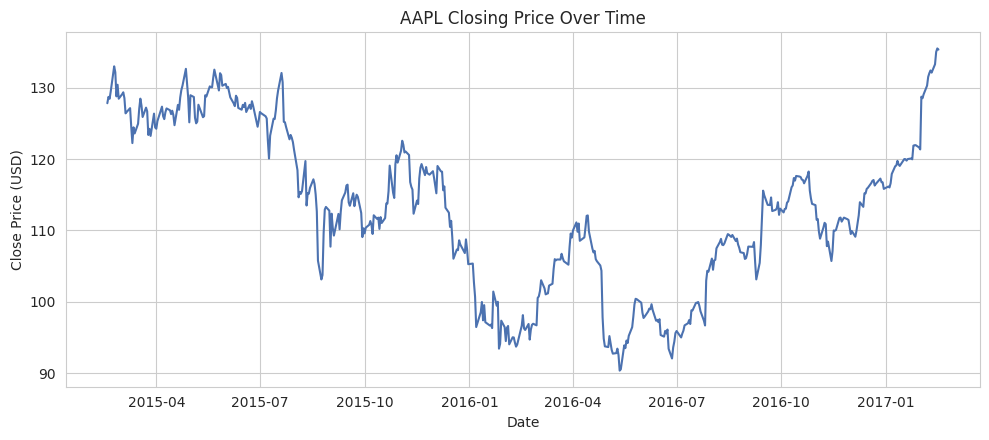

In [5]:
# Closing price over time
plt.figure(figsize=(10, 4.5))
plt.plot(df["Date"], df["Close"], color="#4C72B0")
plt.title(f"{TICKER} Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.tight_layout()
plt.show()


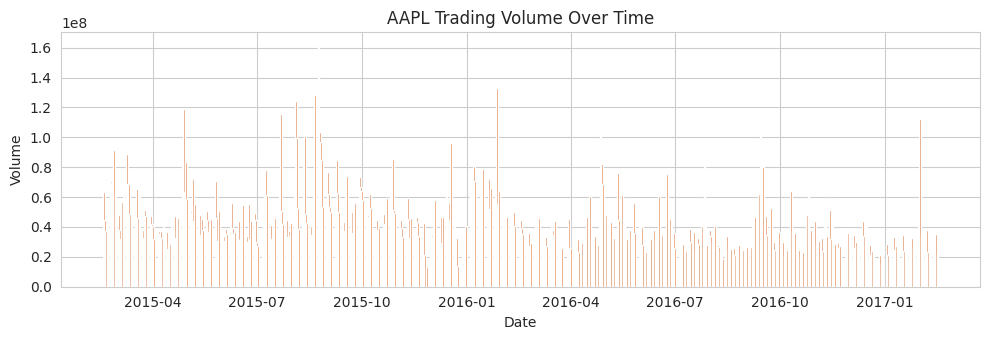

In [6]:
# Trading volume over time
plt.figure(figsize=(10, 3.5))
plt.bar(df["Date"], df["Volume"], color="#DD8452", width=1.5)
plt.title(f"{TICKER} Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()


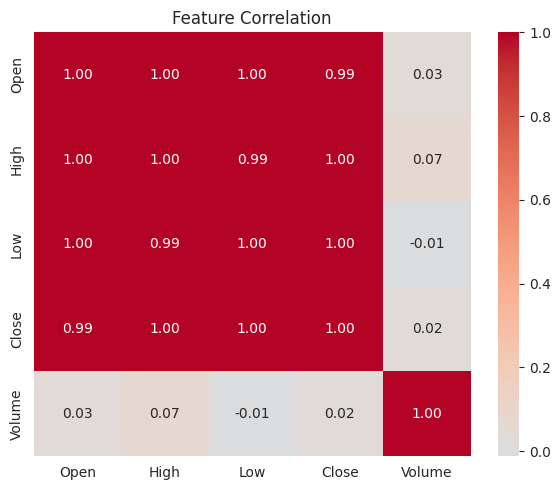

In [7]:
# Correlation between OHLCV features
plt.figure(figsize=(6, 5))
corr = df[["Open", "High", "Low", "Close", "Volume"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation")
plt.tight_layout()
plt.show()


## 3. Feature Preparation

We frame this as: *given today's Open, High, Low, and Volume, predict
today's Close* (the task's suggested feature set). For a true "next day"
forecast, the same features are shifted one day forward — both versions are
shown below.

Because this is **time-series data**, the train/test split must preserve
chronological order (`shuffle=False`) — randomly shuffling would let the
model "see the future" during training, which is not a fair test.

In [8]:
features = ["Open", "High", "Low", "Volume"]

X = df[features]
y = df["Close"]

# Time-aware split — no shuffling, last 20% of days held out as test set
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = df["Date"].iloc[split_idx:]

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))


Training samples: 404
Test samples: 102


## 4. Model Training

In [9]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)


In [10]:
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=RANDOM_STATE)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)


## 5. Model Evaluation

In [11]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"  MAE  : {mae:.3f}")
    print(f"  RMSE : {rmse:.3f}")
    print(f"  R^2  : {r2:.4f}\n")
    return mae, rmse, r2

mae_lin, rmse_lin, r2_lin = evaluate(y_test, y_pred_lin, "Linear Regression")
mae_rf, rmse_rf, r2_rf = evaluate(y_test, y_pred_rf, "Random Forest")


Linear Regression
  MAE  : 0.371
  RMSE : 0.517
  R^2  : 0.9940

Random Forest
  MAE  : 0.598
  RMSE : 0.886
  R^2  : 0.9823



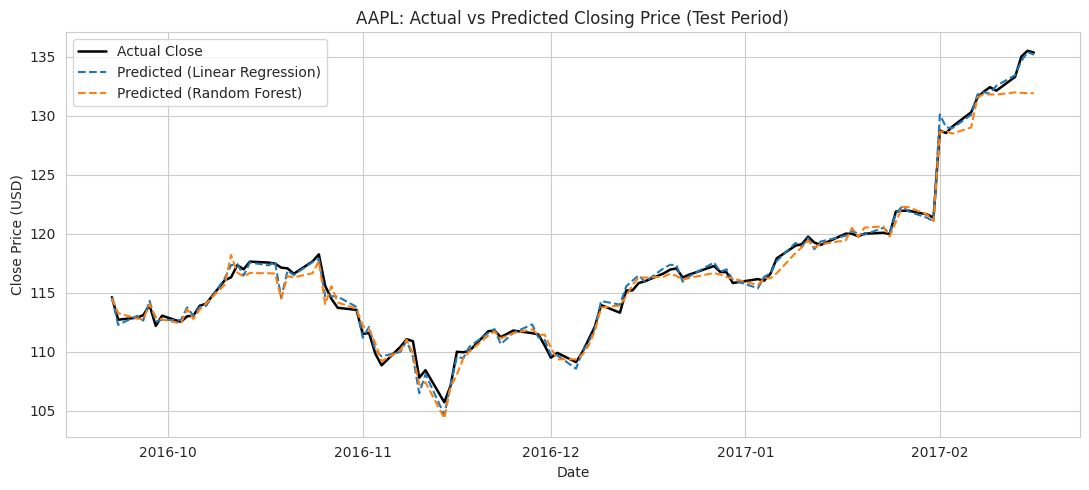

In [12]:
# Actual vs Predicted closing price over the test period
plt.figure(figsize=(11, 5))
plt.plot(dates_test, y_test.values, label="Actual Close", color="black", linewidth=1.8)
plt.plot(dates_test, y_pred_lin, label="Predicted (Linear Regression)", linestyle="--")
plt.plot(dates_test, y_pred_rf, label="Predicted (Random Forest)", linestyle="--")
plt.title(f"{TICKER}: Actual vs Predicted Closing Price (Test Period)")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()


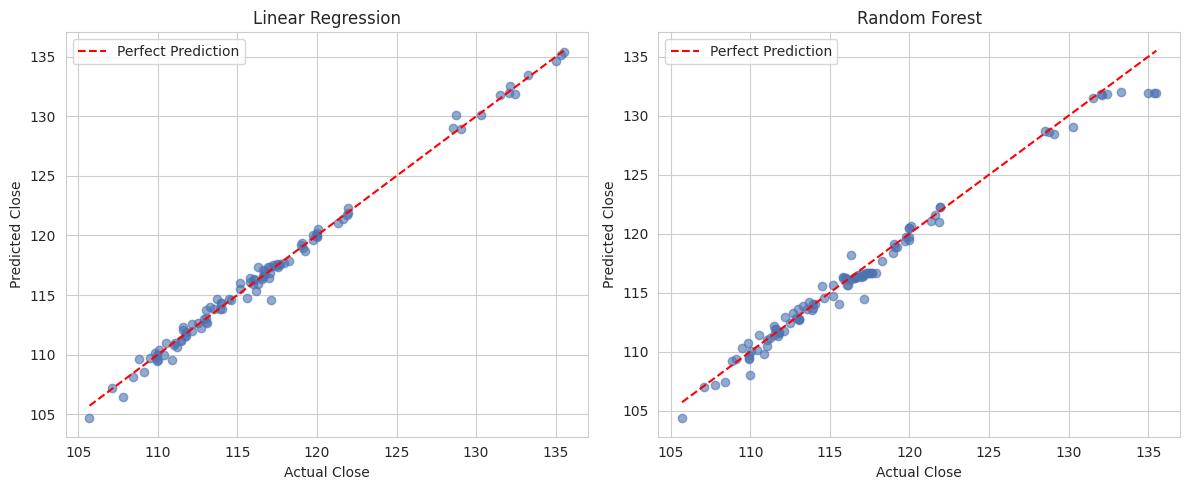

In [13]:
# Scatter view: predicted vs actual for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, name in zip(axes, [y_pred_lin, y_pred_rf], ["Linear Regression", "Random Forest"]):
    ax.scatter(y_test, preds, alpha=0.6, color="#4C72B0")
    lims = [y_test.min(), y_test.max()]
    ax.plot(lims, lims, "--", color="red", label="Perfect Prediction")
    ax.set_xlabel("Actual Close")
    ax.set_ylabel("Predicted Close")
    ax.set_title(name)
    ax.legend()
plt.tight_layout()
plt.show()


## 6. Conclusion & Insights

- Because `Open`, `High`, and `Low` are all extremely close to `Close` on
  the same trading day, **both models predict the same-day closing price
  very accurately** — this task is closer to interpolation than true
  forecasting.
- **Linear Regression** performs strongly here precisely because the
  relationship between same-day OHLC values is close to linear — Random
  Forest doesn't have much room to add value on top of that.
- **True next-day prediction is a much harder problem**: it would require
  using *yesterday's* features (or technical indicators like moving
  averages and RSI) to predict *today's* close, since using today's own
  High/Low to predict today's Close is information the model wouldn't
  actually have in advance, in a real trading scenario.
- **Next steps**: reframe the target as `Close.shift(-1)` using only
  features known *before* the next day begins, add technical indicators
  (moving averages, RSI, MACD), and consider an LSTM for genuine sequential
  modeling.

> **Disclaimer:** This is an educational exercise, not financial advice.
> Stock prices are influenced by countless real-world factors this model
> does not capture.
